Este cuaderno delimita tres nociones que la práctica suele confundir —**interpretabilidad**, **explicabilidad** y **causalidad**— y establece, mediante simulaciones controladas, por qué una asociación estadística fuerte no implica una relación causal. El desarrollo sigue el formato de un **texto matemático**: definiciones numeradas, **proposiciones con demostración** y observaciones que construyen la intuición. Constituye la base conceptual de los nueve cuadernos siguientes.

Contenido:

1. **Definiciones y marco**: las tres nociones, la taxonomía de la XAI y la escalera de la causalidad de Pearl.
2. **Asociación frente a causa**: cuatro mecanismos (correlación espuria, confusión, paradoja de Simpson y colisionador), cada uno con su definición, su proposición y su verificación numérica.
3. **Caso de estudio**: un modelo de *scoring* crediticio (German Credit), transversal a la serie.
4. **Implicaciones**: transparencia, riesgo y límites de la explicación asociacional.

## Contenido

| Sección | Tema | Resultado |
|---|---|---|
| 0 | Preparación del entorno y datos | base reproducible |
| 1 | Definiciones y taxonomía de XAI | marco conceptual |
| 2 | Cuatro experimentos: espuria · confusión · Simpson · colisionador | evidencia de que asociación ≠ causa |
| 3 | German Credit: modelo transparente frente a caja negra | importancia ≠ efecto causal |
| 4 | Transparencia, riesgo y límites | implicaciones prácticas |

**Objetivos.** Al finalizar, el lector podrá: (i) distinguir interpretabilidad, explicabilidad y causalidad; (ii) clasificar un método de XAI según su momento, alcance y dependencia del modelo; (iii) demostrar con simulaciones por qué una asociación fuerte puede no ser causal; (iv) ubicar la explicabilidad en la escalera de la causalidad de Pearl.

**Prerrequisitos.** Python, `pandas`, `scikit-learn` y regresión. **Tiempo estimado:** 90–120 min.

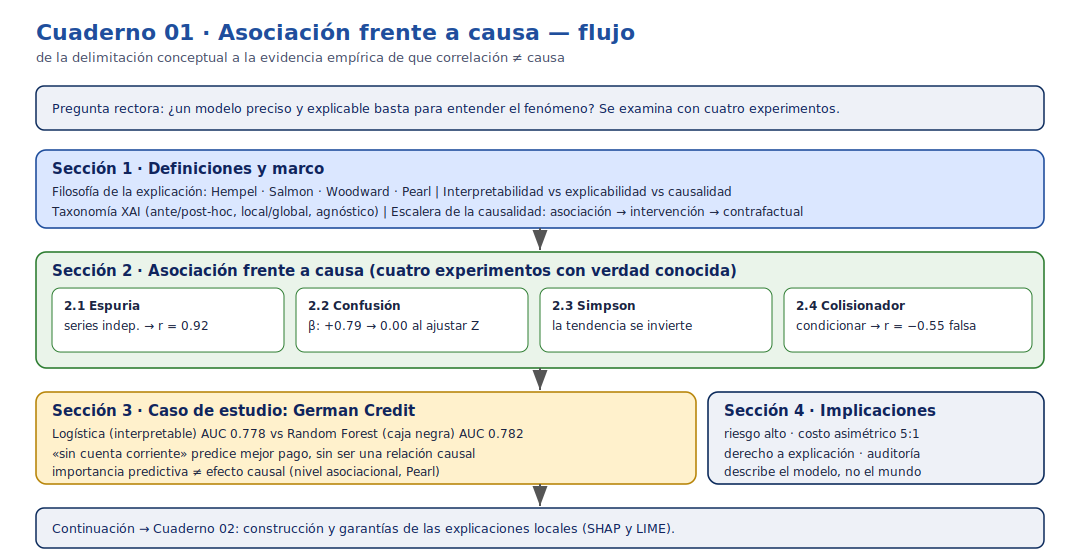

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/01_flujo.svg')
if not _svg.exists():
    _svg = Path('img/01_flujo.svg')
display(SVG(filename=str(_svg)))

## Motivación: el límite de la explicación asociacional

Considérese un modelo que predice el incumplimiento crediticio con buen desempeño y al que se aplica un método de explicación (por ejemplo, SHAP). El método indica que, para un solicitante dado, la ausencia de cuenta corriente aumentó la probabilidad de rechazo. La afirmación es correcta respecto del modelo: describe la asociación que este aprendió de los datos.

No obstante, no responde la pregunta relevante para la decisión: si se interviniera abriendo una cuenta a ese solicitante, ¿cambiaría su probabilidad de pago? Esta es una pregunta **intervencional**, y un método que opera sobre la distribución observada $P(Y\mid X)$ no puede responderla. La distancia entre explicar el comportamiento del modelo y predecir el efecto de una intervención delimita el objeto de este curso y se formaliza a lo largo de la serie.

In [2]:
# Parte 0 · Preparación del entorno
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hacer visible la carpeta src/ (cargadores de datos del repo)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_german_credit

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})
print("Entorno listo · semilla =", RANDOM_STATE)

Entorno listo · semilla = 42


## Sección 1 · ¿Qué significa *explicar*?

La IA "descubrió" la explicabilidad hacia 2016, pero la filosofía de la ciencia lleva discutiéndola desde 1948. Vale la pena pararse sobre esos hombros.

| Modelo de explicación | Idea central | Eco en la IA actual |
|---|---|---|
| **Nomológico-deductivo** (Hempel & Oppenheim, 1948) | Explicar = deducir el hecho desde leyes generales + condiciones iniciales | reglas, modelos simbólicos |
| **Relevancia estadística** (Salmon, 1971) | Explicar = mostrar qué factores cambian la *probabilidad* del hecho | importancia de variables, SHAP |
| **Causal-mecánico** (Salmon, 1984) | Explicar = exhibir el *mecanismo* que produce el hecho | modelos causales, mediación |
| **Intervencionismo** (Woodward, 2003) | Explicar = responder *"¿qué pasaría si intervenimos?"* | operador *do*, contrafactuales |

Observe el desplazamiento: de **deducir** y **correlacionar** hacia **intervenir**. La XAI *post-hoc* más popular (SHAP, LIME) vive en la fila de la *relevancia estadística*: nos dice qué mueve la probabilidad **según el modelo**. La inferencia causal vive en las dos últimas filas. Todo el curso es el viaje entre esas filas.

**Ejemplo — cuatro formas de "explicar" un impago.** Ante la pregunta *¿por qué este cliente no pagó?*, cada modelo responde de manera distinta:

- *Nomológico-deductivo:* "todo cliente con ingresos bajos y deuda alta impaga; este los cumple" (deducción desde una regularidad).
- *Relevancia estadística:* "su nivel de deuda eleva la probabilidad de impago respecto a la base" (lo que cuantifica SHAP).
- *Causal-mecánico:* "la pérdida del empleo redujo su flujo de caja, mecanismo que conduce al impago".
- *Intervencionista:* "de haber tenido un plan de pagos (intervención), no habría impagado".

Solo las dos últimas afirman algo sobre **causas**; las dos primeras, sobre **asociación**.

### Explicabilidad ≠ interpretabilidad (y ninguna es causalidad)

Tres términos que se usan como sinónimos y no lo son:

- **Interpretabilidad**: grado en que un humano puede entender *por construcción* el mecanismo de un modelo. Una regresión lineal o un árbol corto son interpretables *ante-hoc* (transparentes de nacimiento).
- **Explicabilidad**: capacidad de producir, *después* de entrenado, descripciones entendibles del comportamiento de un modelo (típicamente una **caja negra**). SHAP y LIME son explicabilidad *post-hoc*.
- **Causalidad**: afirmaciones sobre cómo cambia el mundo (o el resultado) si **intervenimos** sobre una variable.

> Rudin (2019) llega a sostener que en decisiones de alto riesgo deberíamos **preferir modelos interpretables** antes que explicar cajas negras. Lipton (2016) advierte que "interpretabilidad" es un término sobrecargado. Molnar (2022) ofrece el mapa más práctico del campo. Guardemos esta tensión: la retomaremos en la Parte 4 y en el cuaderno 10.

La distinción clave para nosotros: **explicar e interpretar describen el *modelo*; la causalidad describe el *mundo*.** Un modelo puede ser perfectamente interpretable y, aun así, sus coeficientes no ser efectos causales.

> **Definición 1.1 (interpretabilidad).** Un modelo es *interpretable* si un ser humano puede comprender su mecanismo **por construcción** (ante-hoc): su forma hace transparente cómo las entradas determinan la salida. Ejemplos: una regresión lineal, un árbol de decisión corto.
>
> **Definición 1.2 (explicabilidad).** Un modelo es *explicable* si, ya entrenado, admite procedimientos **post-hoc** que producen descripciones comprensibles de su comportamiento, sin requerir que su mecanismo interno sea transparente. Ejemplos: SHAP o LIME aplicados a una caja negra.
>
> **Definición 1.3 (efecto causal).** El *efecto causal* de una variable $X$ sobre un resultado $Y$ es el modo en que cambia la distribución **intervenida** $P\big(Y\mid do(X{=}x)\big)$ al variar $x$ —no la distribución observada $P(Y\mid X{=}x)$—.
>
> **Observación 1.1.** Las Definiciones 1.1 y 1.2 describen el **modelo**; la 1.3 describe el **mundo**. Un modelo puede ser perfectamente interpretable y, aun así, sus coeficientes no ser efectos causales. Todo el cuaderno gira en torno a esta separación.

### Una taxonomía mínima de XAI

Para no perdernos entre decenas de métodos, cuatro ejes bastan:

| Eje | Opciones | Ejemplo |
|---|---|---|
| **Momento** | *ante-hoc* (transparente) / *post-hoc* (se explica después) | árbol vs SHAP sobre un *boosting* |
| **Alcance** | *local* (una predicción) / *global* (todo el modelo) | LIME (local) vs importancia por permutación (global) |
| **Dependencia** | *específico* del modelo / *agnóstico* | TreeSHAP (específico) vs KernelSHAP (agnóstico) |
| **Salida** | atribución de importancia / ejemplo / regla / contrafactual | SHAP vs DiCE |

En los cuadernos 02–03 recorreremos esta tabla con experimentos. Por ahora, fíjela: cuando alguien diga "usé XAI", la primera reacción debe ser *"¿en qué casilla de esta tabla?"*.

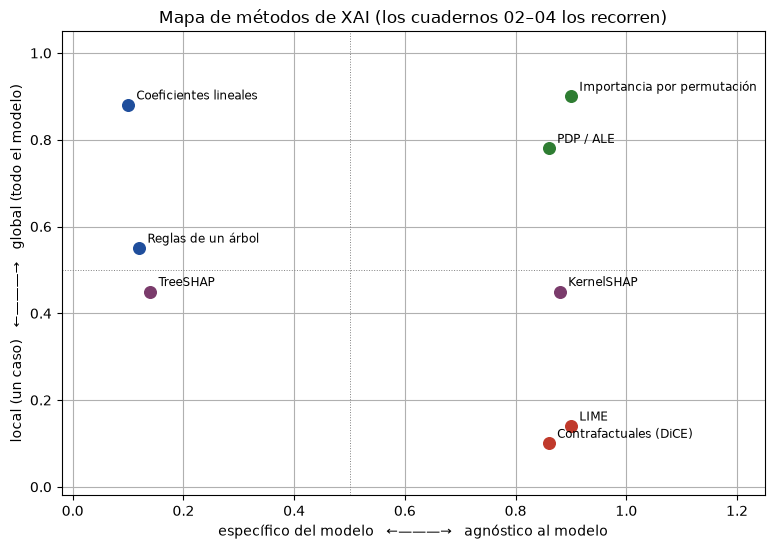

In [3]:
# Figura · mapa de métodos de XAI según alcance y dependencia del modelo
metodos = {
    "Coeficientes lineales":        (0.10, 0.88, "#1f4e9c"),
    "Reglas de un árbol":           (0.12, 0.55, "#1f4e9c"),
    "Importancia por permutación":  (0.90, 0.90, "#2e7d32"),
    "PDP / ALE":                    (0.86, 0.78, "#2e7d32"),
    "TreeSHAP":                     (0.14, 0.45, "#7a3b6b"),
    "KernelSHAP":                   (0.88, 0.45, "#7a3b6b"),
    "LIME":                         (0.90, 0.14, "#c0392b"),
    "Contrafactuales (DiCE)":       (0.86, 0.10, "#c0392b"),
}
fig, ax = plt.subplots(figsize=(8, 5.6))
for nombre, (x, y, c) in metodos.items():
    ax.scatter(x, y, s=70, color=c, zorder=3)
    ax.annotate(nombre, (x, y), fontsize=8.5, xytext=(6, 4), textcoords="offset points")
ax.axhline(0.5, color="gray", lw=.7, ls=":"); ax.axvline(0.5, color="gray", lw=.7, ls=":")
ax.set_xlim(-0.02, 1.25); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("específico del modelo   ←———→   agnóstico al modelo")
ax.set_ylabel("local (un caso)   ←———→   global (todo el modelo)")
ax.set_title("Mapa de métodos de XAI (los cuadernos 02–04 los recorren)")
plt.tight_layout(); plt.show()

### La escalera de la causalidad (Pearl)

Pearl & Mackenzie (2018) organizan el conocimiento en tres peldaños. Es el esquema que mejor ubica nuestro problema:

| Peldaño | Pregunta típica | Operación | ¿Quién vive aquí? |
|---|---|---|---|
| 1. **Asociación** | ¿qué me dice *ver* X sobre Y? | $P(Y\mid X)$ | regresión, ML predictivo, **SHAP/LIME** |
| 2. **Intervención** | ¿qué pasa con Y si *hago* X? | $P(Y\mid do(X))$ | experimentos, DoWhy, EconML |
| 3. **Contrafactual** | ¿qué *habría* pasado si X hubiese sido otro? | $P(Y_{x'}\mid X{=}x, Y{=}y)$ | modelos causales estructurales |

La tesis incómoda del cuaderno: **casi toda la XAI que se usa en la industria vive en el peldaño 1**. Hace transparente la asociación que el modelo aprendió. Subir al peldaño 2 y 3 exige el andamiaje causal de las secciones 2 y 3. Veámoslo ahora con datos.

### Formalización: el modelo causal estructural (SCM)

Un **modelo causal estructural** es una tripleta $\langle U, V, F\rangle$: variables exógenas $U$ (ruido), endógenas $V$ y funciones estructurales $F=\{f_i\}$ tales que cada variable se genera como

$$ V_i := f_i\big(\mathrm{pa}(V_i),\, U_i\big), $$

donde $\mathrm{pa}(V_i)$ son los **padres causales** de $V_i$. A diferencia de una ecuación de regresión, el símbolo $:=$ es **asimétrico**: dice que la izquierda *se produce* a partir de la derecha, no que ambos lados sean intercambiables.

La intervención $do(X=x)$ **borra** la ecuación de $X$ y la reemplaza por la constante $x$, dejando intactas las demás. Por eso, en general,

$$ P\big(Y \mid do(X=x)\big) \;\neq\; P\big(Y \mid X=x\big). $$

Toda la distancia entre los peldaños 1 y 2 de la escalera cabe en esa desigualdad. Los cuatro experimentos que siguen la vuelven tangible.

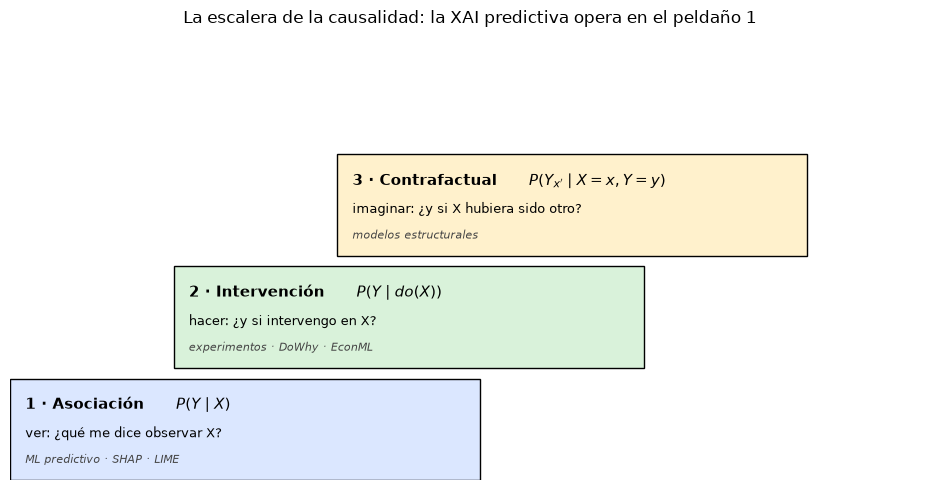

In [4]:
# Figura · la escalera de la causalidad de Pearl
from matplotlib.patches import Rectangle
pasos = [
    ("1 · Asociación",   r"$P(Y\mid X)$",            "ver: ¿qué me dice observar X?",     "ML predictivo · SHAP · LIME",  "#dbe7ff"),
    ("2 · Intervención", r"$P(Y\mid do(X))$",        "hacer: ¿y si intervengo en X?",     "experimentos · DoWhy · EconML","#d9f2da"),
    ("3 · Contrafactual",r"$P(Y_{x'}\mid X{=}x,Y{=}y)$","imaginar: ¿y si X hubiera sido otro?","modelos estructurales",     "#fff1cc"),
]
fig, ax = plt.subplots(figsize=(9.5, 5)); ax.axis("off")
for i, (t, f, q, w, c) in enumerate(pasos):
    x0, y0 = i * 1.6, i * 1.05
    ax.add_patch(Rectangle((x0, y0), 4.6, 0.95, facecolor=c, edgecolor="black"))
    ax.text(x0 + 0.15, y0 + 0.66, f"{t}      {f}", fontsize=11, fontweight="bold")
    ax.text(x0 + 0.15, y0 + 0.40, q, fontsize=9)
    ax.text(x0 + 0.15, y0 + 0.16, w, fontsize=8, style="italic", color="#444")
ax.set_xlim(0, 9); ax.set_ylim(0, 4.2)
ax.set_title("La escalera de la causalidad: la XAI predictiva opera en el peldaño 1")
plt.tight_layout(); plt.show()

## Sección 2 · La trampa de la correlación

Cuatro experimentos cortos. En cada uno, **conocemos la verdad** porque nosotros generamos los datos; eso nos permite ver con nitidez cómo la asociación engaña. Son cuatro maneras distintas en que `corr ≠ causa`:

1. **Correlación espuria** — asociación sin ningún vínculo causal.
2. **Confusión** — una tercera variable produce la asociación.
3. **Paradoja de Simpson** — la asociación *cambia de signo* al agrupar.
4. **Sesgo del colisionador** — *condicionar* crea una asociación que no existía.

### 2.1 Correlación espuria

Dos procesos completamente independientes pueden verse fuertemente correlacionados si ambos tienen **tendencia** (un artefacto clásico de las series de tiempo). No hay causa común ni vínculo: solo coincidencia estructural.

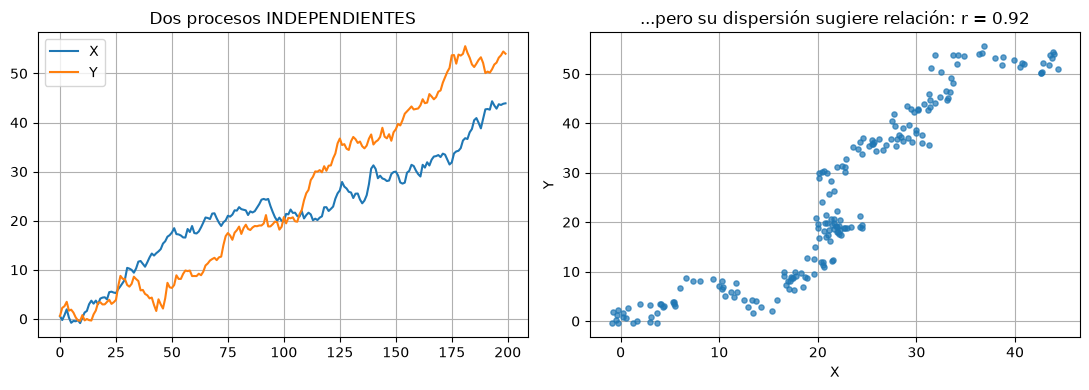

Correlación de Pearson: 0.92  (y sin embargo, X no causa Y ni viceversa)


In [5]:
n = 200
t = np.arange(n)
x = np.cumsum(rng.normal(0.25, 1, n))   # paseo aleatorio con deriva
y = np.cumsum(rng.normal(0.25, 1, n))   # otro, independiente del primero
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, x, label="X"); ax[0].plot(t, y, label="Y")
ax[0].set_title("Dos procesos INDEPENDIENTES"); ax[0].legend()
ax[1].scatter(x, y, s=14, alpha=.7)
ax[1].set_title(f"...pero su dispersión sugiere relación: r = {r:.2f}")
ax[1].set_xlabel("X"); ax[1].set_ylabel("Y")
plt.tight_layout(); plt.show()
print(f"Correlación de Pearson: {r:.2f}  (y sin embargo, X no causa Y ni viceversa)")

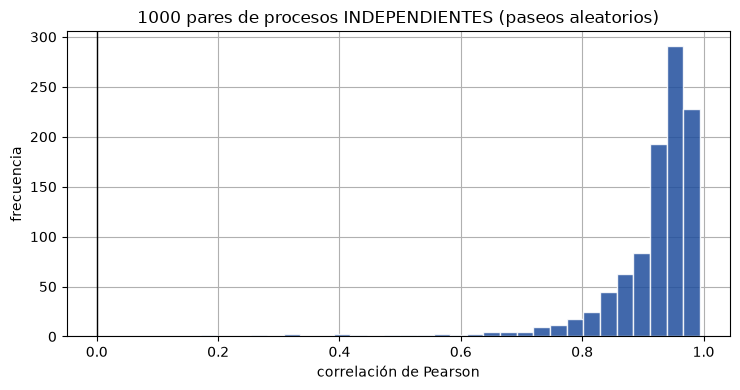

|r| promedio = 0.92   ·   P(|r| > 0.5) = 99%


In [6]:
# Figura · 1000 pares de paseos aleatorios independientes: la correlación espuria es sistemática
def _paseo(n=200):
    return np.cumsum(rng.normal(0.25, 1, n))
sims = np.array([np.corrcoef(_paseo(), _paseo())[0, 1] for _ in range(1000)])
plt.figure(figsize=(7.5, 4))
plt.hist(sims, bins=30, color="#1f4e9c", alpha=.85, edgecolor="white")
plt.axvline(0, color="k", lw=1)
plt.xlabel("correlación de Pearson"); plt.ylabel("frecuencia")
plt.title("1000 pares de procesos INDEPENDIENTES (paseos aleatorios)")
plt.tight_layout(); plt.show()
print(f"|r| promedio = {np.abs(sims).mean():.2f}   ·   P(|r| > 0.5) = {(np.abs(sims) > 0.5).mean():.0%}")

**Por qué ocurre.** Yule (1926) denominó a esto *correlación sin sentido*: dos paseos aleatorios independientes producen, en promedio, correlaciones muestrales **grandes**, porque cada serie acumula tendencias locales persistentes. Phillips (1986) demostró que en este caso el coeficiente muestral **no converge a cero**, sino a una variable aleatoria con varianza apreciable —justo la dispersión del histograma—. La asociación fuerte es la norma, no la excepción, y no implica vínculo causal alguno.

### 2.2 Confusión (*confounding*)

El caso que más daño hace en la práctica. Una variable $Z$ causa a la vez a $X$ y a $Y$. Entonces $X$ e $Y$ aparecen asociadas **aunque $X$ no tenga ningún efecto sobre $Y$**. En nuestro montaje, el efecto causal real de $X$ sobre $Y$ es **exactamente cero**; la regresión ingenua, sin embargo, "verá" un efecto. Al **controlar** por $Z$, el espejismo se desvanece.

In [7]:
from sklearn.linear_model import LinearRegression

n = 3000
Z = rng.normal(0, 1, n)                       # confusor (p. ej., nivel socioeconómico)
X = 0.9 * Z + rng.normal(0, 1, n)             # Z influye en X
Y = 1.6 * Z + 0.0 * X + rng.normal(0, 1, n)   # efecto causal real X->Y = 0

b_naive = LinearRegression().fit(X.reshape(-1, 1), Y).coef_[0]
b_adj   = LinearRegression().fit(np.c_[X, Z], Y).coef_[0]

print(f"Efecto causal verdadero de X sobre Y : 0.00")
print(f"Regresión ingenua  Y ~ X            : beta_X = {b_naive:+.2f}   <- sesgo por confusión")
print(f"Controlando        Y ~ X + Z        : beta_X = {b_adj:+.2f}   <- recupera ~0")
print("\\nMoraleja: 'X importa para predecir Y' es cierto; 'X causa Y' es falso.")

Efecto causal verdadero de X sobre Y : 0.00
Regresión ingenua  Y ~ X            : beta_X = +0.80   <- sesgo por confusión
Controlando        Y ~ X + Z        : beta_X = +0.02   <- recupera ~0
\nMoraleja: 'X importa para predecir Y' es cierto; 'X causa Y' es falso.


> **Definición 2.1 (confusor).** Una variable $Z$ es un *confusor* de la relación entre $X$ e $Y$ si es **causa común** de ambas: $X\leftarrow Z\rightarrow Y$. Induce asociación entre $X$ e $Y$ aunque no exista efecto causal de $X$ sobre $Y$.

> **Proposición 2.1 (sesgo por variable omitida).** Sea el SCM lineal $Z\sim\mathcal N(0,\sigma_Z^2)$, $X:=\alpha Z+\varepsilon_X$, $Y:=\beta X+\gamma Z+\varepsilon_Y$, con ruidos independientes entre sí y de $Z$. La pendiente de la regresión **ingenua** $Y\sim X$ converge en probabilidad a
> $$ \hat b_{\mathrm{ingenuo}}\;\xrightarrow{\;p\;}\;\beta+\gamma\,\frac{\mathrm{Cov}(X,Z)}{\mathrm{Var}(X)}=\beta+\gamma\,\frac{\alpha\,\sigma_Z^2}{\alpha^2\sigma_Z^2+\sigma_{\varepsilon_X}^2}. $$
> El segundo término es el **sesgo por variable omitida**; no se anula salvo que $\gamma=0$ ($Z$ no afecta a $Y$) o $\alpha=0$ ($Z$ no afecta a $X$). Si $\beta=0$, la regresión ingenua "detecta" un efecto inexistente.
>
> **Demostración.** El estimador OLS de la pendiente converge a $\mathrm{Cov}(X,Y)/\mathrm{Var}(X)$. Como $Y=\beta X+\gamma Z+\varepsilon_Y$, por bilinealidad de la covarianza
> $$ \mathrm{Cov}(X,Y)=\beta\,\mathrm{Var}(X)+\gamma\,\mathrm{Cov}(X,Z)+\underbrace{\mathrm{Cov}(X,\varepsilon_Y)}_{=0}. $$
> Dividiendo por $\mathrm{Var}(X)$ resulta $\beta+\gamma\,\mathrm{Cov}(X,Z)/\mathrm{Var}(X)$. Por último, de $X=\alpha Z+\varepsilon_X$ con $\varepsilon_X\perp Z$ se sigue $\mathrm{Cov}(X,Z)=\alpha\sigma_Z^2$ y $\mathrm{Var}(X)=\alpha^2\sigma_Z^2+\sigma_{\varepsilon_X}^2$. $\blacksquare$

> **Definición 2.2 (ajuste de puerta trasera, *back-door*).** Si $Z$ es un confusor, el efecto causal se recupera condicionando sobre $Z$ y promediando con su distribución **marginal**:
> $$ P\big(Y\mid do(X{=}x)\big)=\sum_z P\big(Y\mid X{=}x,\,Z{=}z\big)\,P(Z{=}z). $$

La simulación siguiente confirma la Proposición 2.1: con $\alpha=0.9$, $\gamma=1.6$, $\beta=0$ y $\sigma_Z=\sigma_{\varepsilon_X}=1$, el sesgo teórico es $1.6\cdot 0.9/1.81\approx 0.796$.

In [8]:
alpha, beta, gamma = 0.9, 0.0, 1.6
var_Z, var_epsX = 1.0, 1.0
var_X = alpha**2 * var_Z + var_epsX
sesgo_teorico = beta + gamma * (alpha * var_Z) / var_X
print(f"Sesgo TEÓRICO   beta + gamma·alpha·Var(Z)/Var(X) = {sesgo_teorico:.3f}")
print(f"beta_X EMPÍRICO (regresión ingenua)             = {b_naive:.3f}")
print(f"Diferencia teoría vs simulación                 = {abs(sesgo_teorico - b_naive):.3f}")

Sesgo TEÓRICO   beta + gamma·alpha·Var(Z)/Var(X) = 0.796
beta_X EMPÍRICO (regresión ingenua)             = 0.799
Diferencia teoría vs simulación                 = 0.004


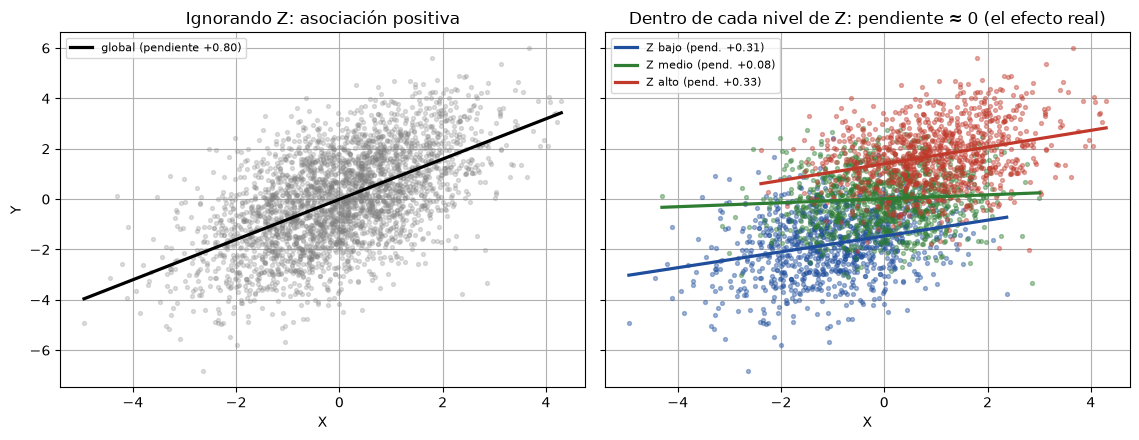

In [9]:
# Figura · confusión: pendiente positiva al ignorar Z, pendiente ≈ 0 dentro de cada nivel de Z
zt = np.asarray(pd.qcut(Z, 3, labels=["Z bajo", "Z medio", "Z alto"]))
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.5), sharey=True)
ax[0].scatter(X, Y, s=8, alpha=.25, color="gray")
m, b = np.polyfit(X, Y, 1); xs = np.linspace(X.min(), X.max(), 50)
ax[0].plot(xs, m * xs + b, color="black", lw=2.3, label=f"global (pendiente {m:+.2f})")
ax[0].set_title("Ignorando Z: asociación positiva"); ax[0].set_ylabel("Y"); ax[0].legend(fontsize=8)
cols = {"Z bajo": "#1f4e9c", "Z medio": "#2e7d32", "Z alto": "#c0392b"}
for lev, c in cols.items():
    mk = zt == lev
    ax[1].scatter(X[mk], Y[mk], s=8, alpha=.4, color=c)
    mm, bb = np.polyfit(X[mk], Y[mk], 1); xs2 = np.linspace(X[mk].min(), X[mk].max(), 30)
    ax[1].plot(xs2, mm * xs2 + bb, color=c, lw=2.3, label=f"{lev} (pend. {mm:+.2f})")
ax[1].set_title("Dentro de cada nivel de Z: pendiente ≈ 0 (el efecto real)"); ax[1].legend(fontsize=8)
for a in ax: a.set_xlabel("X")
plt.tight_layout(); plt.show()

Note la trampa para la XAI: si entrenáramos un modelo de $Y$ con $X$ y $Z$, una explicación tipo SHAP podría asignarle importancia a $X$ (porque *predice* a $Y$ vía su correlación con $Z$). La importancia predictiva es real; la lectura causal sería un error. Este es, en miniatura, el problema que formalizan Ng et al. (2025) y que atacaremos en el cuaderno 04.

### 2.3 La paradoja de Simpson

Es el caso más contraintuitivo: una asociación presente en cada subgrupo puede **invertirse** al combinar los datos. Se ilustra de dos formas complementarias: primero con variables continuas y un diagrama de dispersión —donde la reversión se observa directamente—, y luego con un caso categórico clásico.

#### Demostración con variables continuas: Palmer Penguins

El conjunto **Palmer Penguins** (Horst, Hill & Gorman, 2020), con medidas morfológicas de 342 pingüinos antárticos, es un ejemplo "natural" frecuente de la paradoja. Al relacionar la **longitud** y la **profundidad del pico**, la correlación agregada es **negativa** ($r=-0.24$): aparentaría que los picos más largos son menos profundos. Pero al colorear por **especie** —el grupo, claramente visible en el diagrama de dispersión— la correlación es **positiva** dentro de cada una ($+0.39$, $+0.65$, $+0.64$). La especie es el confusor: condiciona a la vez el tamaño general y la forma del pico. Las rectas de cada grupo suben; la recta agregada (negra, punteada) baja.

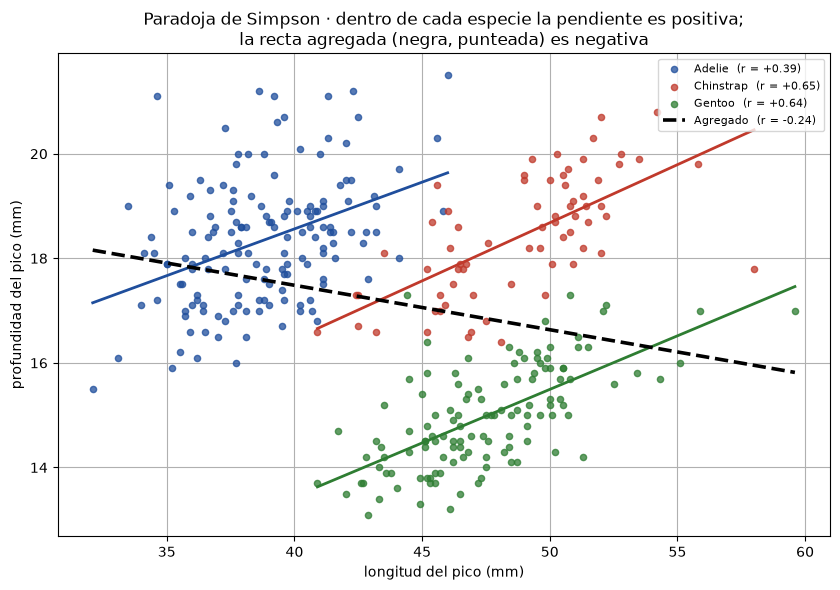

correlación agregada (ignorando la especie): -0.24
  dentro de Adelie    : r = +0.39  (n = 151)
  dentro de Chinstrap : r = +0.65  (n = 68)
  dentro de Gentoo    : r = +0.64  (n = 123)


In [10]:
# Figura · paradoja de Simpson en un diagrama de dispersión (Palmer Penguins)
peng = (pd.read_csv(ROOT / "data" / "raw" / "penguins.csv")
          .dropna(subset=["bill_length_mm", "bill_depth_mm", "species"]))
r_pool = peng["bill_length_mm"].corr(peng["bill_depth_mm"])

fig, ax = plt.subplots(figsize=(8.5, 6))
colores = {"Adelie": "#1f4e9c", "Chinstrap": "#c0392b", "Gentoo": "#2e7d32"}
for sp, d in peng.groupby("species"):
    r = d["bill_length_mm"].corr(d["bill_depth_mm"])
    ax.scatter(d["bill_length_mm"], d["bill_depth_mm"], s=20, alpha=.75,
               color=colores.get(sp, "gray"), label=f"{sp}  (r = {r:+.2f})")
    m, b = np.polyfit(d["bill_length_mm"], d["bill_depth_mm"], 1)
    xs = np.linspace(d["bill_length_mm"].min(), d["bill_length_mm"].max(), 50)
    ax.plot(xs, m * xs + b, color=colores.get(sp, "gray"), lw=2)

m, b = np.polyfit(peng["bill_length_mm"], peng["bill_depth_mm"], 1)   # recta agregada
xs = np.linspace(peng["bill_length_mm"].min(), peng["bill_length_mm"].max(), 50)
ax.plot(xs, m * xs + b, color="black", lw=2.6, ls="--", label=f"Agregado  (r = {r_pool:+.2f})")

ax.set_xlabel("longitud del pico (mm)"); ax.set_ylabel("profundidad del pico (mm)")
ax.set_title("Paradoja de Simpson · dentro de cada especie la pendiente es positiva;\n"
             "la recta agregada (negra, punteada) es negativa")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

print(f"correlación agregada (ignorando la especie): {r_pool:+.2f}")
for sp, d in peng.groupby("species"):
    print(f"  dentro de {sp:10s}: r = {d['bill_length_mm'].corr(d['bill_depth_mm']):+.2f}  (n = {len(d)})")

#### Una instancia categórica: tratamientos para cálculos renales

La paradoja también aparece con proporciones. En un estudio clásico (Charig et al., 1986) sobre dos tratamientos para cálculos renales, el tamaño del cálculo actúa como confusor: condiciona tanto el tratamiento asignado como la probabilidad de éxito.

In [11]:
# Conteos del estudio clásico (éxitos / total) por tamaño del cálculo
filas = [
    ("Cálculos pequeños", "Tratamiento A", 81, 87),
    ("Cálculos pequeños", "Tratamiento B", 234, 270),
    ("Cálculos grandes",  "Tratamiento A", 192, 263),
    ("Cálculos grandes",  "Tratamiento B", 55, 80),
]
tab = pd.DataFrame(filas, columns=["tamaño", "tratamiento", "exitos", "total"])
tab["tasa_exito"] = tab.exitos / tab.total

# Por subgrupo
print("Tasa de éxito POR SUBGRUPO:")
print(tab.pivot(index="tamaño", columns="tratamiento", values="tasa_exito").round(3), "\\n")

# Agregado (ignorando el tamaño)
agg = tab.groupby("tratamiento").apply(lambda d: d.exitos.sum() / d.total.sum())
print("Tasa de éxito AGREGADA (ignorando el tamaño):")
print(agg.round(3))

Tasa de éxito POR SUBGRUPO:
tratamiento        Tratamiento A  Tratamiento B
tamaño                                         
Cálculos grandes           0.730          0.688
Cálculos pequeños          0.931          0.867 \n
Tasa de éxito AGREGADA (ignorando el tamaño):
tratamiento
Tratamiento A    0.780
Tratamiento B    0.826
dtype: float64


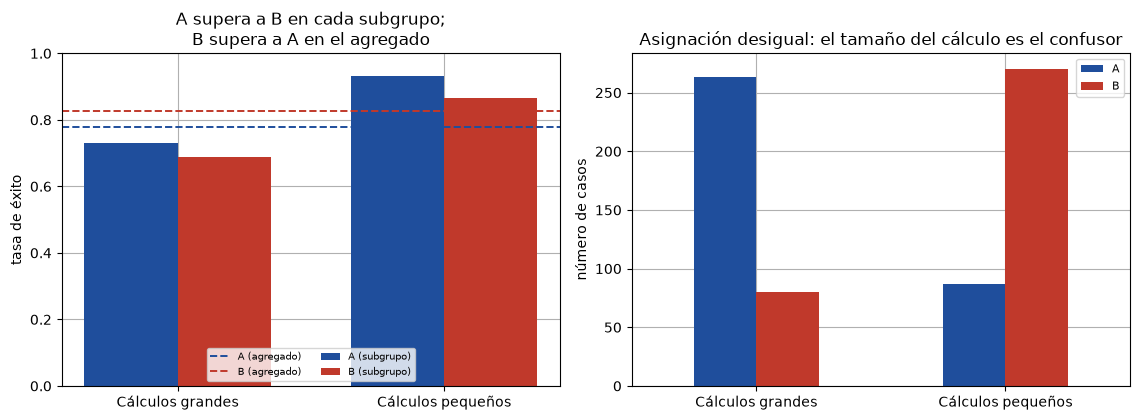

In [12]:
# Figura · reversión de Simpson (tasas por subgrupo vs agregado)
piv = tab.pivot(index="tamaño", columns="tratamiento", values="tasa_exito")
g = tab.groupby("tratamiento")[["exitos", "total"]].sum()
agg = g["exitos"] / g["total"]
tam = tab.pivot(index="tamaño", columns="tratamiento", values="total")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
x = np.arange(len(piv.index)); w = 0.35
ax[0].bar(x - w/2, piv["Tratamiento A"], w, color="#1f4e9c", label="A (subgrupo)")
ax[0].bar(x + w/2, piv["Tratamiento B"], w, color="#c0392b", label="B (subgrupo)")
ax[0].axhline(agg["Tratamiento A"], ls="--", lw=1.4, color="#1f4e9c", label="A (agregado)")
ax[0].axhline(agg["Tratamiento B"], ls="--", lw=1.4, color="#c0392b", label="B (agregado)")
ax[0].set_xticks(x); ax[0].set_xticklabels(piv.index)
ax[0].set_ylabel("tasa de éxito"); ax[0].set_ylim(0, 1)
ax[0].set_title("A supera a B en cada subgrupo;\nB supera a A en el agregado")
ax[0].legend(fontsize=7, loc="lower center", ncol=2)
tam.plot(kind="bar", ax=ax[1], color=["#1f4e9c", "#c0392b"])
ax[1].set_title("Asignación desigual: el tamaño del cálculo es el confusor")
ax[1].set_ylabel("número de casos"); ax[1].set_xlabel("")
ax[1].set_xticklabels(tam.index, rotation=0); ax[1].legend(["A", "B"], fontsize=8)
plt.tight_layout(); plt.show()

### Lectura y mecanismo de la reversión

El **Tratamiento A** tiene mayor tasa de éxito en cálculos pequeños (93 % frente a 87 %) y también en grandes (73 % frente a 69 %); sin embargo, en el agregado **B** parece superior (83 % frente a 78 %). No hay error aritmético: la tasa agregada de cada tratamiento es un **promedio ponderado** de sus tasas por subgrupo, con pesos iguales a la proporción de casos en cada uno,

$$ \text{tasa}_A = \frac{n_A^{\text{peq}}}{n_A}\,p_A^{\text{peq}} + \frac{n_A^{\text{gra}}}{n_A}\,p_A^{\text{gra}}. $$

El Tratamiento A se administró mayoritariamente a **cálculos grandes** (peor pronóstico) y B a **pequeños** (mejor pronóstico), como muestra el panel derecho. Son esos pesos —y no la eficacia— los que arrastran el promedio de A hacia abajo. El tamaño del cálculo es un **confusor**: influye tanto en la asignación del tratamiento como en el desenlace.

La decisión de **estratificar y no agregar** proviene del conocimiento causal, no de los datos. El estimador correcto pondera por la distribución **marginal** del confusor (ajuste *back-door*),

$$ P(\text{éxito}\mid do(\text{trat})) = \sum_{z} P(\text{éxito}\mid \text{trat}, z)\,P(z), $$

y no por la distribución condicional al tratamiento, que es la que produce el agregado engañoso. Esta estructura se formaliza con DAGs en el cuaderno 06.

> **Proposición 2.2 (condición de reversión de Simpson).** Sean dos subgrupos $g\in\{1,2\}$. Bajo el tratamiento $A$, sea $w^A_g\ge 0$ la proporción de casos de $A$ en el grupo $g$ (con $w^A_1+w^A_2=1$) y $p^A_g$ su tasa de éxito; análogamente para $B$. Las tasas agregadas son los promedios ponderados
> $$ \bar p^A=w^A_1 p^A_1+w^A_2 p^A_2,\qquad \bar p^B=w^B_1 p^B_1+w^B_2 p^B_2. $$
> Entonces es posible que $p^A_g>p^B_g$ para **cada** $g$ y, sin embargo, $\bar p^A<\bar p^B$.
>
> **Demostración (por construcción).** Como $\bar p^A$ es una combinación convexa de $p^A_1,p^A_2$, si $A$ concentra su masa en el grupo de peor pronóstico (digamos $w^A_2\to 1$ con $p^A_2$ bajo) y $B$ la concentra en el de mejor pronóstico ($w^B_1\to 1$ con $p^B_1$ alto), entonces $\bar p^A\to p^A_2$ y $\bar p^B\to p^B_1$. Eligiendo $p^A_2<p^B_1$ se obtiene $\bar p^A<\bar p^B$ pese a la dominancia por grupo. $\blacksquare$
>
> **Observación 2.2.** La reversión no es un error aritmético sino el efecto de un confusor (el grupo) sobre la **asignación** ($w$) y sobre el **desenlace** ($p$). Qué tabla "creer" —agregada o por grupo— es una decisión **causal**, no estadística: si el grupo es confusor, se estratifica.

### 2.4 El sesgo del colisionador (un anticipo)

El más contraintuitivo, y por eso el más peligroso. Si $X$ e $Y$ son **independientes** pero ambos causan a $C$ (un *colisionador*), entonces **condicionar** sobre $C$ —filtrar, estratificar, seleccionar la muestra— **crea** una correlación entre $X$ e $Y$ que no existía. Aquí "controlar una variable más" *empeora* el análisis.

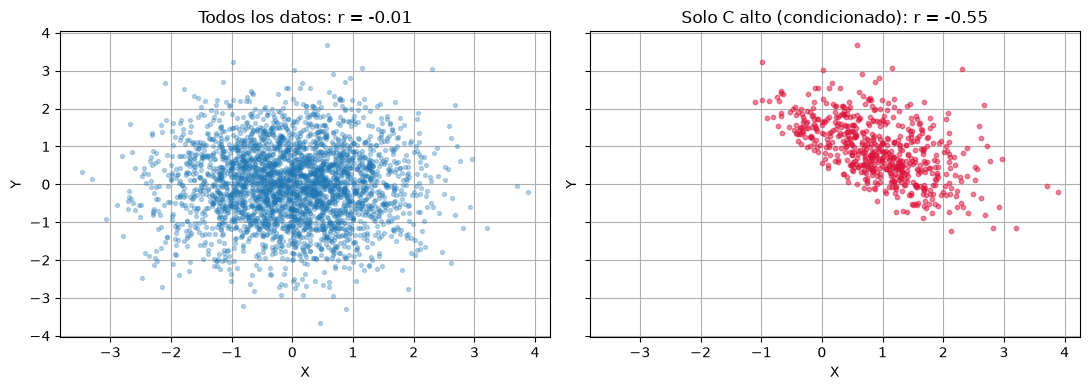

corr(X,Y) global        = -0.01  (≈ 0, como debe ser)
corr(X,Y) | C alto       = -0.55  (¡correlación inducida por condicionar!)


In [13]:
n = 3000
X = rng.normal(0, 1, n)
Y = rng.normal(0, 1, n)            # X e Y son independientes por construcción
C = X + Y + rng.normal(0, 0.4, n)  # C es causado por ambos (colisionador)

r_todos = np.corrcoef(X, Y)[0, 1]
sel = C > np.quantile(C, 0.80)     # condicionamos: nos quedamos con C alto
r_cond = np.corrcoef(X[sel], Y[sel])[0, 1]

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
ax[0].scatter(X, Y, s=8, alpha=.3); ax[0].set_title(f"Todos los datos: r = {r_todos:+.2f}")
ax[1].scatter(X[sel], Y[sel], s=10, alpha=.5, color="crimson")
ax[1].set_title(f"Solo C alto (condicionado): r = {r_cond:+.2f}")
for a in ax: a.set_xlabel("X"); a.set_ylabel("Y")
plt.tight_layout(); plt.show()
print(f"corr(X,Y) global        = {r_todos:+.2f}  (≈ 0, como debe ser)")
print(f"corr(X,Y) | C alto       = {r_cond:+.2f}  (¡correlación inducida por condicionar!)")

> **Definición 2.3 (colisionador).** Una variable $C$ es un *colisionador* en un camino si es **efecto común** de dos variables: $X\rightarrow C\leftarrow Y$. A diferencia del confusor, $X$ e $Y$ pueden ser independientes; condicionar sobre $C$ (o sobre un descendiente suyo) **induce** dependencia entre ellas —el llamado *sesgo del colisionador* o de selección—.

> **Proposición 2.3 (correlación inducida por un colisionador).** Sean $X\perp Y$ y $C:=X+Y+\varepsilon_C$, con $\varepsilon_C$ independiente. La **correlación parcial** de $X$ e $Y$ dado $C$ es
> $$ \rho_{XY\cdot C}=\frac{\rho_{XY}-\rho_{XC}\,\rho_{YC}}{\sqrt{(1-\rho_{XC}^2)(1-\rho_{YC}^2)}}\;<\;0. $$
>
> **Demostración.** La correlación parcial es la correlación entre los residuos de regresar $X$ y $Y$ sobre $C$; su forma cerrada es la expresión anterior. Por hipótesis $X\perp Y$, luego $\rho_{XY}=0$ y el numerador se reduce a $-\rho_{XC}\rho_{YC}$. Como $C$ depende positivamente de $X$ y de $Y$ (coeficientes $+1$), $\mathrm{Cov}(X,C)=\mathrm{Var}(X)>0$ y $\mathrm{Cov}(Y,C)=\mathrm{Var}(Y)>0$, de donde $\rho_{XC},\rho_{YC}>0$. El numerador es entonces negativo y el denominador positivo, así que $\rho_{XY\cdot C}<0$. $\blacksquare$
>
> **Observación 2.3.** Aquí "controlar una variable más" **empeora** el análisis: condicionar sobre el colisionador fabrica una asociación inexistente. Estratificar por $C$ alto, como en el código de abajo, es una forma de condicionar.

In [14]:
def _corr(a, b): return np.corrcoef(a, b)[0, 1]
rho_XY, rho_XC, rho_YC = _corr(X, Y), _corr(X, C), _corr(Y, C)
rho_parcial = (rho_XY - rho_XC * rho_YC) / np.sqrt((1 - rho_XC**2) * (1 - rho_YC**2))
print(f"rho_XY   (marginal)         = {rho_XY:+.3f}   (≈ 0: X e Y son independientes)")
print(f"rho_XY·C (parcial, teoría)  = {rho_parcial:+.3f}   <- negativa: el colisionador la induce")

rho_XY   (marginal)         = -0.010   (≈ 0: X e Y son independientes)
rho_XY·C (parcial, teoría)  = -0.870   <- negativa: el colisionador la induce


**Síntesis de la Sección 2.** La asociación puede inducir conclusiones erróneas por al menos cuatro mecanismos distintos: coincidencia (2.1), confusión (2.2), agregación inadecuada (2.3) y condicionamiento sobre un colisionador (2.4). Ningún método que opere únicamente sobre $P(Y\mid X)$ los distingue por sí solo; se requiere especificar la estructura causal, objeto de la Sección 2.

> **Definición 2.4 (resultados potenciales).** Para un tratamiento binario $T\in\{0,1\}$, cada unidad $i$ posee dos *resultados potenciales* $Y_i(1)$ e $Y_i(0)$: su resultado bajo cada tratamiento. Solo se observa uno,
> $$ Y_i = T_i\,Y_i(1) + (1-T_i)\,Y_i(0), $$
> lo que constituye el **problema fundamental de la inferencia causal**. El efecto promedio del tratamiento es $\mathrm{ATE}=\mathbb E[Y(1)-Y(0)]$.

> **Proposición 2.4 (descomposición de la diferencia ingenua).** La diferencia de medias observada entre tratados y controles se descompone como
> $$ \underbrace{\mathbb E[Y\mid T{=}1]-\mathbb E[Y\mid T{=}0]}_{\text{asociación}}=\underbrace{\mathbb E[Y(1)-Y(0)\mid T{=}1]}_{\text{ATT}}+\underbrace{\mathbb E[Y(0)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]}_{\text{sesgo de selección}}. $$
>
> **Demostración.** Por consistencia, $\mathbb E[Y\mid T{=}1]=\mathbb E[Y(1)\mid T{=}1]$ y $\mathbb E[Y\mid T{=}0]=\mathbb E[Y(0)\mid T{=}0]$. Restando y sumando $\mathbb E[Y(0)\mid T{=}1]$:
> $$ \mathbb E[Y(1)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]=\big(\mathbb E[Y(1)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}1]\big)+\big(\mathbb E[Y(0)\mid T{=}1]-\mathbb E[Y(0)\mid T{=}0]\big). $$
> El primer paréntesis es el ATT; el segundo, el sesgo de selección. $\blacksquare$
>
> **Observación 2.4.** La **aleatorización** (cuaderno 05) anula el sesgo de selección al forzar $Y(0)\perp T$; el **ajuste causal** (cuadernos 06–08) lo neutraliza condicionando sobre los confusores correctos. Ningún método de XAI toca este término.

## Sección 3 · Nuestro caso guía: *German Credit*

Bajemos de las simulaciones a un dato real que nos acompañará todo el recorrido: **German Credit** (1000 solicitantes, etiquetados como buen/mal pagador). Es perfecto para el curso porque es de alto impacto (decisiones crediticias), tiene variables sensibles (sexo, edad, condición de extranjero) y un costo de error asimétrico.

In [15]:
df = load_german_credit()
print("Dimensiones:", df.shape)
print("Proporción de buen pagador:", round(df["riesgo_bueno"].mean(), 3))
df[["estado_cuenta", "duracion_meses", "monto_credito", "edad", "proposito",
    "sexo", "riesgo_bueno"]].head()

Dimensiones: (1000, 23)
Proporción de buen pagador: 0.7


,estado_cuenta,duracion_meses,monto_credito,edad,proposito,sexo,riesgo_bueno
0,< 0 DM,6,1169,67,radio/TV,hombre,1
1,0-200 DM,48,5951,22,radio/TV,mujer,0
2,sin cuenta,12,2096,49,educación,hombre,1
3,< 0 DM,42,7882,45,mobiliario,hombre,1
4,< 0 DM,24,4870,53,carro nuevo,hombre,0


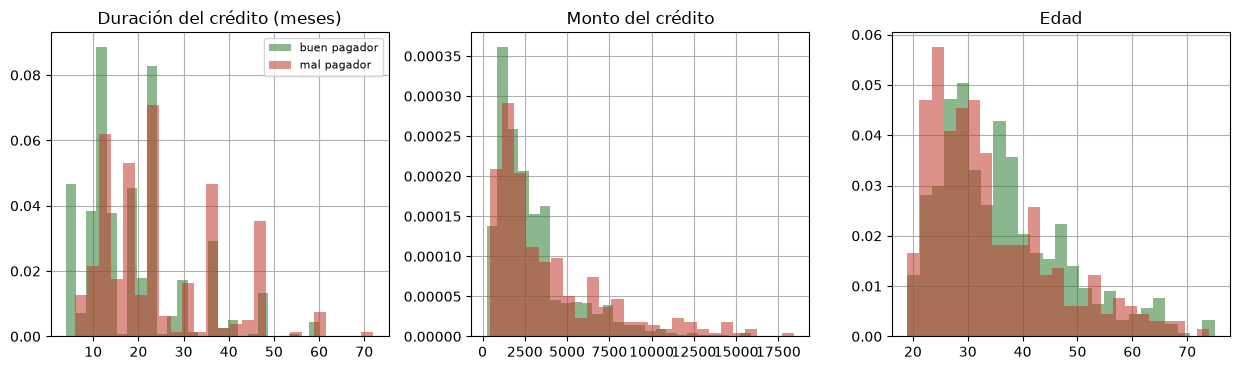

In [16]:
# Figura · distribución de variables numéricas por clase (EDA)
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.8))
for a, col, titulo in zip(ax, ["duracion_meses", "monto_credito", "edad"],
                          ["Duración del crédito (meses)", "Monto del crédito", "Edad"]):
    for cls, color, lab in [(1, "#2e7d32", "buen pagador"), (0, "#c0392b", "mal pagador")]:
        a.hist(df.loc[df.riesgo_bueno == cls, col], bins=25, alpha=.55,
               color=color, label=lab, density=True)
    a.set_title(titulo)
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

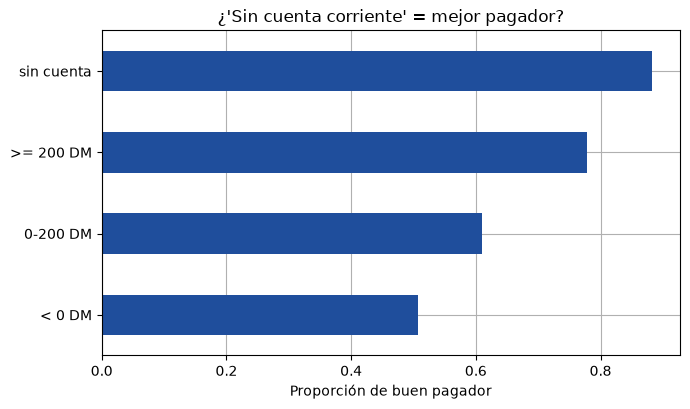

                mean  count
estado_cuenta              
< 0 DM         0.507    274
0-200 DM       0.610    269
>= 200 DM      0.778     63
sin cuenta     0.883    394


In [17]:
# Tasa de buen pagador según el estado de la cuenta corriente
tasa = (df.groupby("estado_cuenta")["riesgo_bueno"]
          .agg(["mean", "count"]).sort_values("mean"))
ax = tasa["mean"].plot(kind="barh", color="#1f4e9c")
ax.set_xlabel("Proporción de buen pagador"); ax.set_ylabel("")
ax.set_title("¿'Sin cuenta corriente' = mejor pagador?")
plt.tight_layout(); plt.show()
print(tasa.round(3))

Se observa un patrón conocido en este conjunto: los solicitantes **sin cuenta corriente** presentan una tasa de pago superior a la de quienes la tienen con saldo bajo. Esto no implica que eliminar la cuenta mejore el comportamiento de pago: es una asociación derivada del muestreo, no una relación causal. La distinción entre asociación observada e intervención se retoma formalmente en la Sección 2.

### Modelo transparente vs caja negra

Entrenemos dos modelos sobre los mismos datos:
- una **regresión logística** (interpretable *ante-hoc*),
- un **random forest** (caja negra que luego, en el cuaderno 02, explicaremos con SHAP).

Compararemos su desempeño y, sobre todo, leeremos qué nos dice cada uno —recordando que *importancia predictiva* no es *efecto causal*.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

y = df["riesgo_bueno"]
X = pd.get_dummies(df.drop(columns=["riesgo", "riesgo_bueno", "estado_personal_sexo"]),
                   drop_first=True)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

logit = LogisticRegression(max_iter=3000).fit(X_tr, y_tr)
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_tr, y_tr)

auc_logit = roc_auc_score(y_te, logit.predict_proba(X_te)[:, 1])
auc_rf    = roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1])
print(f"AUC  regresión logística (interpretable): {auc_logit:.3f}")
print(f"AUC  random forest (caja negra)        : {auc_rf:.3f}")

C:\Users\cizai\AppData\Local\venvs\icx\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC  regresión logística (interpretable): 0.778
AUC  random forest (caja negra)        : 0.782


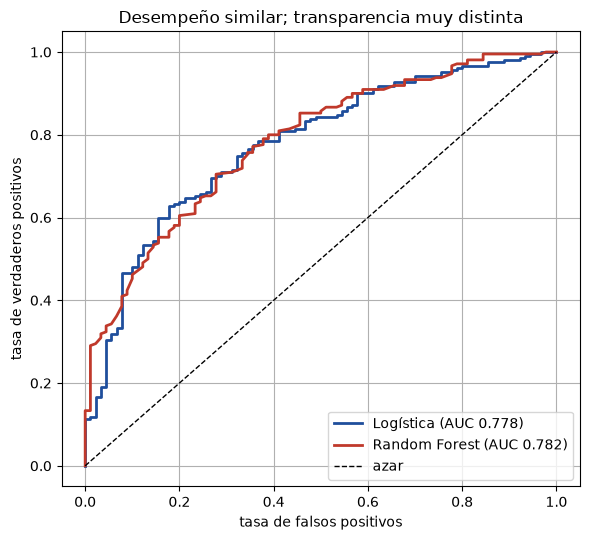

In [19]:
# Figura · curvas ROC: modelo interpretable vs caja negra
from sklearn.metrics import roc_curve
plt.figure(figsize=(6, 5.5))
for nombre, mdl, col in [("Logística", logit, "#1f4e9c"), ("Random Forest", rf, "#c0392b")]:
    pr = mdl.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, pr)
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{nombre} (AUC {roc_auc_score(y_te, pr):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="azar")
plt.xlabel("tasa de falsos positivos"); plt.ylabel("tasa de verdaderos positivos")
plt.title("Desempeño similar; transparencia muy distinta")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [20]:
from sklearn.inspection import permutation_importance

# (a) Coeficientes de la logística: dirección e intensidad (en log-odds)
coef = (pd.Series(logit.coef_[0], index=X.columns)
          .sort_values(key=np.abs, ascending=False).head(8))
print("Logística — variables más influyentes (signo = dirección):")
print(coef.round(2), "\\n")

# (b) Importancia por permutación del random forest (global, agnóstica)
imp = permutation_importance(rf, X_te, y_te, n_repeats=15,
                             random_state=RANDOM_STATE, scoring="roc_auc")
top = (pd.Series(imp.importances_mean, index=X.columns)
         .sort_values(ascending=False).head(8))
print("Random forest — importancia por permutación (caída de AUC):")
print(top.round(4))

Logística — variables más influyentes (signo = dirección):
proposito_carro usado                       1.77
estado_cuenta_sin cuenta                    1.14
otros_deudores_A103                         1.09
trabajador_extranjero_A202                  0.95
proposito_radio/TV                          0.85
historial_credito_crítica/otros créditos    0.84
ahorros_>= 1000 DM                          0.83
propiedad_sin propiedad/desconocido        -0.73
dtype: float64 \n


Random forest — importancia por permutación (caída de AUC):
estado_cuenta_sin cuenta                   0.0560
estado_cuenta_< 0 DM                       0.0231
duracion_meses                             0.0121
edad                                       0.0095
monto_credito                              0.0086
propiedad_inmueble                         0.0085
otros_planes_pago_A143                     0.0072
historial_credito_pagados en este banco    0.0062
dtype: float64


Ambos modelos coinciden en señalar al **estado de la cuenta corriente** y a la **duración/monto** del crédito como muy informativos. Pero lea con cuidado lo que *significa* eso:

- La logística dice: *"manteniendo lo demás fijo, esta variable mueve los log-odds en tal dirección"* — una afirmación **asociacional y dependiente del modelo**, no un efecto de intervenir.
- La importancia por permutación dice: *"si rompo la relación de esta variable con el objetivo, el AUC cae tanto"* — mide **cuánto la usa el modelo**, no cuánto *importa en la realidad*.

Ninguna responde *"¿qué pasaría con el pago si interviniéramos sobre esta variable?"*. Estamos, otra vez, firmemente en el **peldaño 1** de la escalera de Pearl.

## Sección 4 · ¿Por qué importa la transparencia?

Si la explicabilidad solo describe correlaciones, ¿para qué sirve? Para mucho —siempre que sepamos qué pregunta responde y cuál no:

- **Decisiones de alto impacto.** En crédito, salud o justicia, una predicción opaca que afecta vidas exige rendición de cuentas. La XAI permite *auditar* el comportamiento del modelo (cuaderno 10).
- **Costo asimétrico.** En German Credit, la matriz de costos oficial penaliza **5×** clasificar a un mal pagador como bueno frente al error contrario. Explicar *por qué* el modelo aprobó un caso dudoso es económicamente relevante.
- **Derecho a explicación.** Marcos como el RGPD europeo y discusiones regulatorias en Colombia empujan hacia decisiones algorítmicas explicables.
- **Confianza y detección de atajos.** La XAI revela cuando un modelo se apoya en correlaciones frágiles o variables sensibles (sexo, nacionalidad) — una alerta ética, aunque no resuelva la causalidad.

> La gran limitación —y la razón de ser de este curso— es que la explicabilidad **describe el modelo, no el mundo**. Confiar en una explicación correlacional para *intervenir* es el error que Carloni et al. (2023) señalan como el límite estructural de la XAI actual.

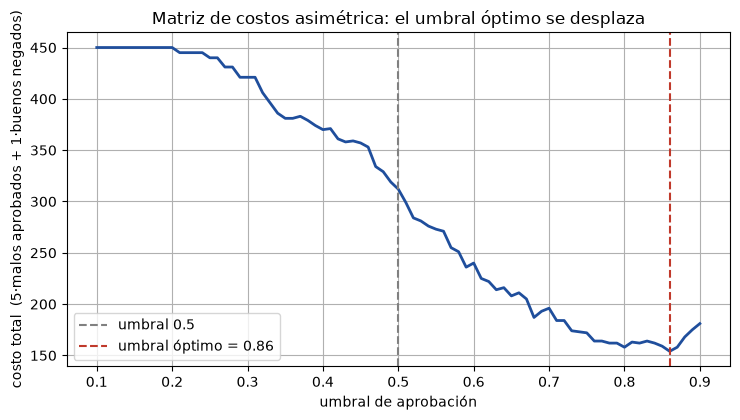

costo en umbral 0.5 = 312   ·   costo mínimo = 154 en umbral 0.86


In [21]:
# Figura · el costo asimétrico (5:1) desplaza el umbral óptimo de decisión
p_rf = rf.predict_proba(X_te)[:, 1]            # prob. de buen pagador
ths = np.linspace(0.10, 0.90, 81)
costos = []
for t in ths:
    aprob = (p_rf >= t).astype(int)            # 1 = conceder el crédito
    malos_aprobados = int(((aprob == 1) & (y_te.values == 0)).sum())   # costo 5 c/u
    buenos_negados  = int(((aprob == 0) & (y_te.values == 1)).sum())   # costo 1 c/u
    costos.append(5 * malos_aprobados + 1 * buenos_negados)
costos = np.array(costos)
t_opt = ths[costos.argmin()]
plt.figure(figsize=(7.5, 4.3))
plt.plot(ths, costos, color="#1f4e9c", lw=2)
plt.axvline(0.5, ls="--", color="gray", label="umbral 0.5")
plt.axvline(t_opt, ls="--", color="#c0392b", label=f"umbral óptimo = {t_opt:.2f}")
plt.xlabel("umbral de aprobación"); plt.ylabel("costo total  (5·malos aprobados + 1·buenos negados)")
plt.title("Matriz de costos asimétrica: el umbral óptimo se desplaza")
plt.legend(); plt.tight_layout(); plt.show()
c_05 = costos[np.argmin(np.abs(ths - 0.5))]
print(f"costo en umbral 0.5 = {c_05}   ·   costo mínimo = {costos.min()} en umbral {t_opt:.2f}")

El costo mínimo **no** se alcanza en el umbral 0.5. Como aprobar a un mal pagador cuesta cinco veces más que rechazar a uno bueno, el umbral óptimo se desplaza hacia arriba (la política se vuelve más exigente). Por eso una explicación que aclare *por qué* el modelo asignó a un caso una probabilidad cercana al umbral es económicamente relevante: es justo donde el costo esperado del error es mayor. La explicación, sin embargo, sigue siendo asociacional; no dice qué *intervención* reduciría el impago.

## Síntesis

Este cuaderno estableció:

1. *Interpretabilidad*, *explicabilidad* y *causalidad* son nociones distintas: las dos primeras describen el modelo; la tercera, el efecto de intervenir en el mundo.
2. La asociación puede inducir error por coincidencia, confusión, agregación o condicionamiento sobre un colisionador, según se mostró con simulaciones y su formalización.
3. Los métodos de XAI predictiva (SHAP, LIME, importancia) operan en el nivel asociacional (peldaño 1 de la escalera de Pearl).
4. Pese a ello, la transparencia es relevante por razones de riesgo, costo, regulación y auditoría.

**Continuación.** El cuaderno 02 desarrolla la construcción y las garantías de las explicaciones locales (SHAP y LIME), aplicadas a la caja negra entrenada en la Sección 3.

*(El diagrama de flujo del cuaderno se muestra al inicio.)*

## Ejemplos complementarios

Tres ejemplos desarrollados que extienden los resultados de las secciones anteriores.

### Ejemplo 1 · La deriva amplifica la correlación espuria

Se repite el experimento 2.1 variando la **deriva** de los paseos aleatorios independientes y se mide la correlación espuria media y la frecuencia con que supera 0.9.

In [22]:
print(f"{'deriva':>8} | {'|r| medio':>9} | {'P(|r| > 0.9)':>12}")
for deriva in [0.0, 0.05, 0.15, 0.30, 0.50]:
    sims = np.array([np.corrcoef(np.cumsum(rng.normal(deriva, 1, 200)),
                                 np.cumsum(rng.normal(deriva, 1, 200)))[0, 1]
                     for _ in range(400)])
    print(f"{deriva:8.2f} | {np.abs(sims).mean():9.2f} | {(np.abs(sims) > 0.9).mean():12.0%}")

  deriva | |r| medio | P(|r| > 0.9)
    0.00 |      0.43 |           2%
    0.05 |      0.46 |           4%
    0.15 |      0.74 |          26%
    0.30 |      0.95 |          90%
    0.50 |      0.98 |         100%


A mayor deriva, mayor correlación espuria: con deriva suficiente, dos procesos **independientes** superan $|r|>0.9$ en una fracción enorme de los casos.

### Ejemplo 2 · Magnitud del sesgo de confusión

Se evalúa el sesgo de la regresión ingenua, $\gamma\,\alpha\,\mathrm{Var}(Z)/\mathrm{Var}(X)$, sobre una malla de $\gamma$ (efecto de $Z$ sobre $Y$) y $\alpha$ (efecto de $Z$ sobre $X$).

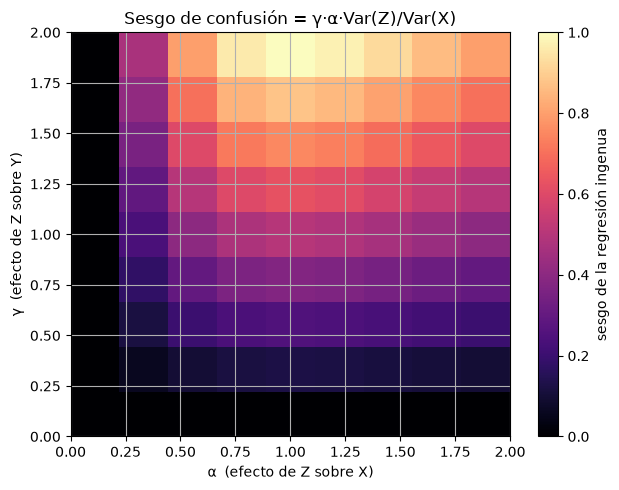

El sesgo crece con γ y con α; es nulo si Z no afecta a X (α=0) o a Y (γ=0).


In [23]:
gammas = np.linspace(0, 2, 9); alphas = np.linspace(0, 2, 9)
B = np.array([[g * a * 1.0 / (a**2 * 1.0 + 1.0) for a in alphas] for g in gammas])
plt.figure(figsize=(6.4, 5))
im = plt.imshow(B, origin="lower", cmap="magma", aspect="auto",
                extent=[alphas.min(), alphas.max(), gammas.min(), gammas.max()])
plt.colorbar(im, label="sesgo de la regresión ingenua")
plt.xlabel("α  (efecto de Z sobre X)"); plt.ylabel("γ  (efecto de Z sobre Y)")
plt.title("Sesgo de confusión = γ·α·Var(Z)/Var(X)")
plt.tight_layout(); plt.show()
print("El sesgo crece con γ y con α; es nulo si Z no afecta a X (α=0) o a Y (γ=0).")

### Ejemplo 3 · ¿Aparece la paradoja de Simpson en German Credit?

Se examina la correlación entre el **monto del crédito** y la condición de **buen pagador**, globalmente y dentro de cada **propósito** del crédito.

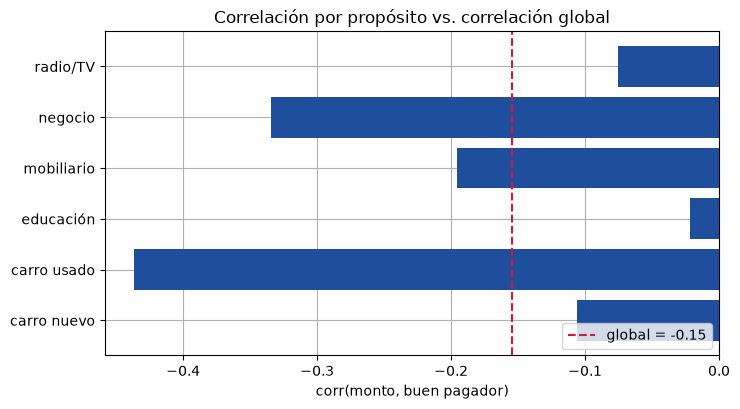

correlación global: -0.155
  carro nuevo      r = -0.106
  carro usado      r = -0.436
  educación        r = -0.022
  mobiliario       r = -0.196
  negocio          r = -0.335
  radio/TV         r = -0.075


In [24]:
r_glob = df["monto_credito"].corr(df["riesgo_bueno"])
gr = {p: d["monto_credito"].corr(d["riesgo_bueno"])
      for p, d in df.groupby("proposito") if len(d) >= 40}
plt.figure(figsize=(7.5, 4.2))
plt.barh(list(gr), list(gr.values()), color="#1f4e9c")
plt.axvline(r_glob, color="crimson", ls="--", label=f"global = {r_glob:+.2f}")
plt.xlabel("corr(monto, buen pagador)"); plt.legend(loc="lower right")
plt.title("Correlación por propósito vs. correlación global")
plt.tight_layout(); plt.show()
print(f"correlación global: {r_glob:+.3f}")
for p, r in gr.items():
    print(f"  {p:16s} r = {r:+.3f}")

La correlación global es negativa (montos mayores → menor probabilidad de buen pagador), pero **varía de intensidad —e incluso de signo— según el propósito**. El propósito actúa como variable de agrupación que modula la relación, una manifestación del mismo fenómeno que la paradoja de Simpson.

### Ejemplo 4 · Sesgo de colisionador en datos de crédito

Caso realista del fenómeno 2.4: si solo se analiza a los solicitantes **aprobados**, se condiciona sobre un colisionador (la aprobación depende de ingresos *e* historial), lo que induce correlación donde no la había.

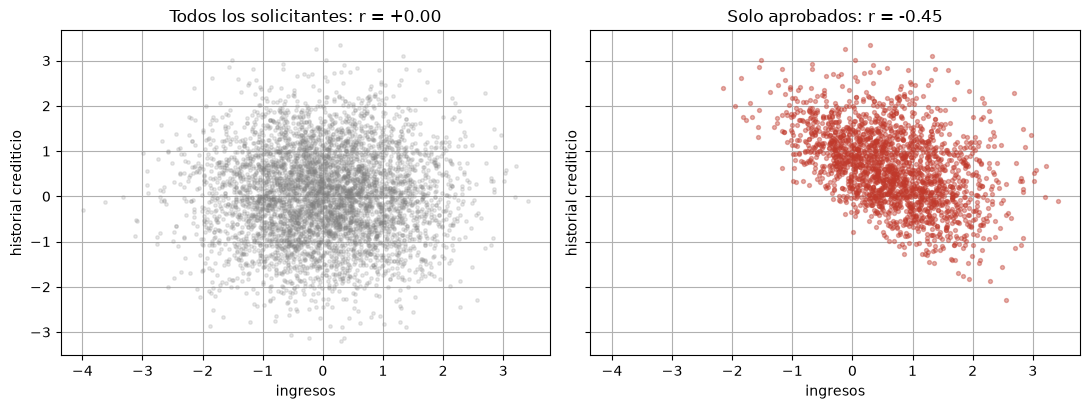

Analizar solo a los aprobados induce una correlación negativa espuria (+0.00 -> -0.45) entre ingresos e historial.


In [25]:
n = 5000
ingresos = rng.normal(0, 1, n)                      # independientes...
historial = rng.normal(0, 1, n)                     # ...entre sí
score = ingresos + historial + rng.normal(0, 0.5, n)
aprobado = score > np.quantile(score, 0.60)         # se aprueba el 40% con mejor score (colisionador)

r_todos = np.corrcoef(ingresos, historial)[0, 1]
r_aprob = np.corrcoef(ingresos[aprobado], historial[aprobado])[0, 1]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
ax[0].scatter(ingresos, historial, s=6, alpha=.18, color="gray")
ax[0].set_title(f"Todos los solicitantes: r = {r_todos:+.2f}")
ax[1].scatter(ingresos[aprobado], historial[aprobado], s=8, alpha=.4, color="#c0392b")
ax[1].set_title(f"Solo aprobados: r = {r_aprob:+.2f}")
for a in ax: a.set_xlabel("ingresos"); a.set_ylabel("historial crediticio")
plt.tight_layout(); plt.show()
print(f"Analizar solo a los aprobados induce una correlación negativa espuria "
      f"({r_todos:+.2f} -> {r_aprob:+.2f}) entre ingresos e historial.")

### Ejemplo 5 · ¿Explicar una caja negra o usar un modelo interpretable?

Versión empírica del debate Rudin (2019) vs. la práctica de la XAI: se mide la **ganancia real** de la caja negra sobre el modelo interpretable en este problema.

In [26]:
from sklearn.metrics import roc_auc_score
auc_int = roc_auc_score(y_te, logit.predict_proba(X_te)[:, 1])
auc_bb = roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1])
print(f"AUC modelo interpretable (logística) : {auc_int:.3f}")
print(f"AUC caja negra (random forest)       : {auc_bb:.3f}")
print(f"Ganancia de la caja negra            : {auc_bb - auc_int:+.3f}")

AUC modelo interpretable (logística) : 0.778
AUC caja negra (random forest)       : 0.782
Ganancia de la caja negra            : +0.004


En este conjunto la ganancia es prácticamente nula: la posición de Rudin (2019) —preferir un modelo interpretable antes que explicar una caja negra— está bien fundamentada **cuando la brecha de desempeño es pequeña**. La explicabilidad *post-hoc* se justifica sobre todo cuando esa brecha es grande, escenario habitual con datos no tabulares (texto, imágenes).

## Referencias (APA 7)

- Carloni, G., Berti, A., & Colantonio, S. (2023). *The role of causality in explainable artificial intelligence* [Preprint]. arXiv:2309.09901.
- Charig, C. R., Webb, D. R., Payne, S. R., & Wickham, J. E. (1986). Comparison of treatment of renal calculi by open surgery, percutaneous nephrolithotomy, and extracorporeal shockwave lithotripsy. *British Medical Journal, 292*(6524), 879–882.
- Hempel, C. G., & Oppenheim, P. (1948). Studies in the logic of explanation. *Philosophy of Science, 15*(2), 135–175.
- Horst, A. M., Hill, A. P., & Gorman, K. B. (2020). *palmerpenguins: Palmer Archipelago (Antarctica) penguin data* [R package]. https://allisonhorst.github.io/palmerpenguins/
- Lipton, Z. C. (2016). *The mythos of model interpretability* [Preprint]. arXiv:1606.03490.
- Molnar, C. (2022). *Interpretable machine learning: A guide for making black box models explainable* (2nd ed.).
- Moraffah, R., Karami, M., Guo, R., Raglin, A., & Liu, H. (2020). Causal interpretability for machine learning: Problems, methods and evaluation. *ACM SIGKDD Explorations, 22*(1), 18–33.
- Ng, W. Y., Wang, L. R., Liu, S., & Fan, X. (2025). *Causal SHAP: Feature attribution with dependency awareness through causal discovery* [Preprint]. arXiv:2509.00846.
- Pearl, J., & Mackenzie, D. (2018). *The book of why: The new science of cause and effect*. Basic Books.
- Rudin, C. (2019). Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead. *Nature Machine Intelligence, 1*, 206–215.
- Salmon, W. C. (1984). *Scientific explanation and the causal structure of the world*. Princeton University Press.
- Woodward, J. (2003). *Making things happen: A theory of causal explanation*. Oxford University Press.